# Phân tích và dự đoán giá tai nghe/headphone từ thông số kỹ thuật

**Bài thi giữa kỳ môn Khai thác dữ liệu (KHDL)**  
Nhóm 2 người.

---

## 0. Phát biểu bài toán

- **Mục tiêu:** Phân tích dữ liệu để đánh giá **khả thi** xây dựng mô hình **dự đoán giá tai nghe/headphone (Y)** từ các thông số kỹ thuật và thuộc tính sản phẩm (X₁, X₂, …).
- **Loại bài toán:** **Hồi quy (Regression)** — biến mục tiêu Y là số (giá VND).
- **Câu hỏi cần trả lời:**
  1. Bài toán có khả thi với dữ liệu thu thập được không? Vì sao?
  2. Nếu khả thi, tập **đặc trưng hữu ích** dùng để xây dựng mô hình là gì (ví dụ: hãng, loại tai nghe, kích thước driver, trở kháng, thời lượng pin, ANC, Bluetooth, đánh giá, số lượt review…)?

*Phần mô hình hóa chi tiết (training, đánh giá) dành cho bài GK tập trung thu thập, làm sạch, mã hóa, feature engineering, trực quan hóa và kết luận.*

---

## Data and Setup

**Import thư viện:** numpy, pandas, matplotlib, seaborn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

---

## 1. Thu thập dữ liệu

### 1.1 Nguồn và cách thu thập

- **Nguồn:** Dữ liệu tai nghe/headphone **tự thu thập (crawl)** từ các trang thương mại điện tử.
- **Gợi ý nguồn:** `gearvn.com`, `cellphones.com.vn`, `phongvu.vn`, `pcpartpicker.com` (có thể bổ sung Tiki, Shopee nếu cần).
- **Công cụ:** Python (`requests`, `BeautifulSoup`, `lxml` hoặc `selenium` nếu trang render JS nhiều).
- **Quy trình:**
  1. Vào trang danh sách tai nghe (có phân trang) của từng website.
  2. Thu thập link từng sản phẩm.
  3. Vào từng trang chi tiết, trích xuất: tên, giá, hãng, loại tai nghe, kiểu kết nối (wireless/wired/TWS), kích thước driver, trở kháng, độ nhạy, Bluetooth version, thời lượng pin, có/không ANC, có/không micro, chống nước, trọng lượng, bảo hành, đánh giá, số review…
  4. Lưu ra file CSV (raw data) trong thư mục `raw_data/`.
- **Code crawl:** đặt trong thư mục `scripts/` (ví dụ `crawl_gearvn_headphone.py`). Chạy: `python scripts/crawl_*.py` → file CSV lưu trong `raw_data/`. 

### 1.2 Đường dẫn file dữ liệu

Chỉnh `RAW_CSV` cho đúng file CSV raw bạn đã crawl (trong `raw_data/`).

In [2]:
# Thư mục project: nếu đang chạy từ notebooks/ thì lên 1 cấp
PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
RAW_DIR = os.path.join(PROJECT_DIR, 'raw_data')
CLEAN_DIR = os.path.join(PROJECT_DIR, 'clean_data')

# File raw: đổi tên file cho đúng file bạn đã crawl
RAW_CSV = os.path.join(RAW_DIR, 'headphone_gearvn_YYYYMMDD_HHMMSS.csv')  # Ví dụ; thay bằng file thực tế bạn crawl

# Nếu chưa có file raw, liệt kê file trong raw_data để chọn
if os.path.isdir(RAW_DIR):
    files = [f for f in os.listdir(RAW_DIR) if f.endswith('.csv')]
    if files:
        RAW_CSV = os.path.join(RAW_DIR, files[-1])  # Lấy file mới nhất
    print('File raw đang dùng:', RAW_CSV)
else:
    print('Chưa có thư mục raw_data hoặc chưa crawl. Tạo file mẫu để chạy thử.')
    RAW_CSV = None

File raw đang dùng: c:\Study\KHDL\GK\de_tai_2_headphone\raw_data\raw_data.csv


### 1.3 Đọc dữ liệu raw vào DataFrame

In [3]:
if RAW_CSV and os.path.isfile(RAW_CSV):
    df = pd.read_csv(RAW_CSV, encoding='utf-8')
    print(f'Đã đọc {len(df)} dòng, {len(df.columns)} cột.')
else:
    # DataFrame mẫu để chạy thử notebook (khi chưa có file crawl)
    df = pd.DataFrame({
        'name': ['Tai nghe A', 'Tai nghe B', 'Tai nghe C'] * 50,
        'price_vnd': [500000, 1200000, 2500000] * 50,
        'brand': ['Sony', 'JBL', 'Logitech'] * 50,
        'type': ['over-ear', 'in-ear', 'gaming'] * 50,
        'connection': ['wireless', 'wired', 'wireless'] * 50,
        'driver_size_mm': [40, 10, 50] * 50,
        'impedance_ohm': [32, 16, 64] * 50,
        'sensitivity_db': [98, 102, 95] * 50,
        'battery_life_hours': [30, 0, 20] * 50,
        'has_anc': [1, 0, 0] * 50,
        'has_mic': [1, 1, 1] * 50,
        'water_resistant': [0, 1, 0] * 50,
        'weight_gram': [250, 50, 320] * 50,
        'warranty_months': [12, 12, 24] * 50,
        'rating': [4.5, 4.7, 4.3] * 50,
        'num_reviews': [120, 300, 80] * 50,
    })
    print('Đang dùng dữ liệu MẪU (150 dòng tai nghe). Sau khi crawl xong, đọc file CSV thật.')

Đã đọc 1037 dòng, 13 cột.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   source              1037 non-null   object 
 1   url                 1037 non-null   object 
 2   name                1030 non-null   object 
 3   price_raw           1032 non-null   object 
 4   price_vnd           1037 non-null   int64  
 5   brand               1026 non-null   object 
 6   type                269 non-null    object 
 7   is_gaming           1026 non-null   float64
 8   is_wireless         1026 non-null   float64
 9   has_mic             1026 non-null   float64
 10  connection          428 non-null    object 
 11  battery_life_hours  339 non-null    float64
 12  weight_gram         346 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 105.4+ KB


In [5]:
df.head(10)

,source,url,name,price_raw,price_vnd,brand,type,is_gaming,is_wireless,has_mic,connection,battery_life_hours,weight_gram
0,cellphones,https://cellphones.com.vn/tai-nghe-khong-day-a...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cellphones,https://cellphones.com.vn/tai-nghe-khong-day-s...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cellphones,https://cellphones.com.vn/tai-nghe-bluetooth-x...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cellphones,https://cellphones.com.vn/tai-nghe-bluetooth-x...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cellphones,https://cellphones.com.vn/tai-nghe-samsung-gal...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,cellphones,https://cellphones.com.vn/tai-nghe-khong-day-s...,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,cellphones,https://cellphones.com.vn/thiet-bi-am-thanh/ta...,"Tai nghe bluetooth, không dây",4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-so...,Tai nghe Bluetooth chụp tai Sony WH-1000XM6,11.990.000đ,11990000,Sony,over-ear,0.0,1.0,0.0,3.5mm,40.0,254.0
9,cellphones,https://cellphones.com.vn/tai-nghe-chup-tai-se...,Tai nghe chụp tai Sennheiser HDB 630,14.900.000đ,14900000,Sennheiser,over-ear,0.0,0.0,0.0,NaN,60.0,NaN


---

## 2. Thống kê mô tả — Trực quan đơn biến

Xuất **thống kê mô tả trực quan** cho một vài biến quan trọng (minh họa).

In [6]:
# Biến số: describe
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    display(df[numeric_cols].describe())

,price_vnd,is_gaming,is_wireless,has_mic,battery_life_hours
count,1.037000e+03,1026.000000,1026.000000,1026.000000,339.000000
mean,3.798084e+06,0.164717,0.519493,0.010721,23.091445
std,8.673791e+06,0.371106,0.499864,0.103037,28.595121
min,0.000000e+00,0.000000,0.000000,0.000000,2.000000
25%,6.400000e+05,0.000000,0.000000,0.000000,7.000000
50%,1.690000e+06,0.000000,1.000000,0.000000,9.000000
75%,5.000000e+06,0.000000,1.000000,0.000000,30.000000
max,1.689900e+08,1.000000,1.000000,1.000000,240.000000


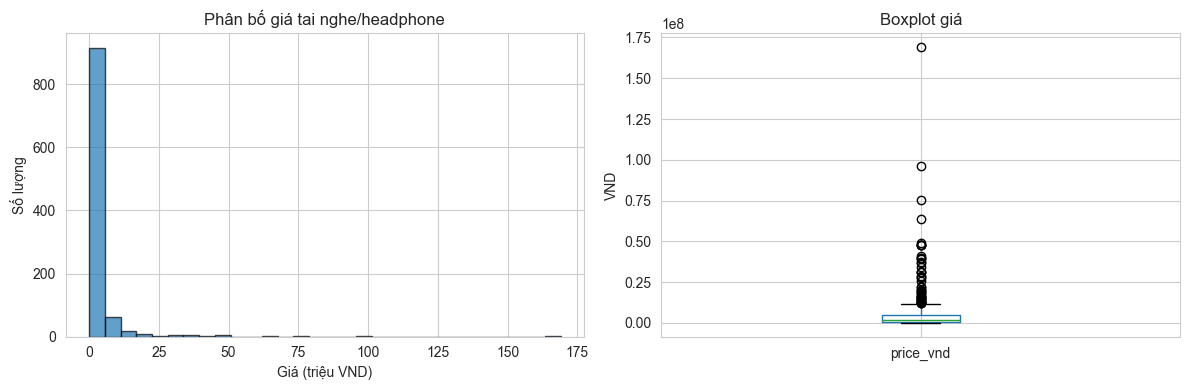

In [7]:
# Phân bố giá (price_vnd)
if 'price_vnd' in df.columns:
    df_valid_price = df[df['price_vnd'].notna() & (df['price_vnd'] > 0)]
    if len(df_valid_price) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(df_valid_price['price_vnd'] / 1e6, bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Giá (triệu VND)')
        axes[0].set_ylabel('Số lượng')
        axes[0].set_title('Phân bố giá tai nghe/headphone')
        df_valid_price.boxplot(column='price_vnd', ax=axes[1])
        axes[1].set_ylabel('VND')
        axes[1].set_title('Boxplot giá')
        plt.tight_layout()
        plt.show()

In [8]:
# Phân bố RAM (nếu có)
if 'ram_gb' in df.columns:
    ram_ok = df[df['ram_gb'].notna() & (df['ram_gb'] > 0)]
    if len(ram_ok) > 0:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=ram_ok, x='ram_gb', order=ram_ok['ram_gb'].value_counts().index)
        plt.xlabel('RAM (GB)')
        plt.title('Phân bố dung lượng RAM')
        plt.show()

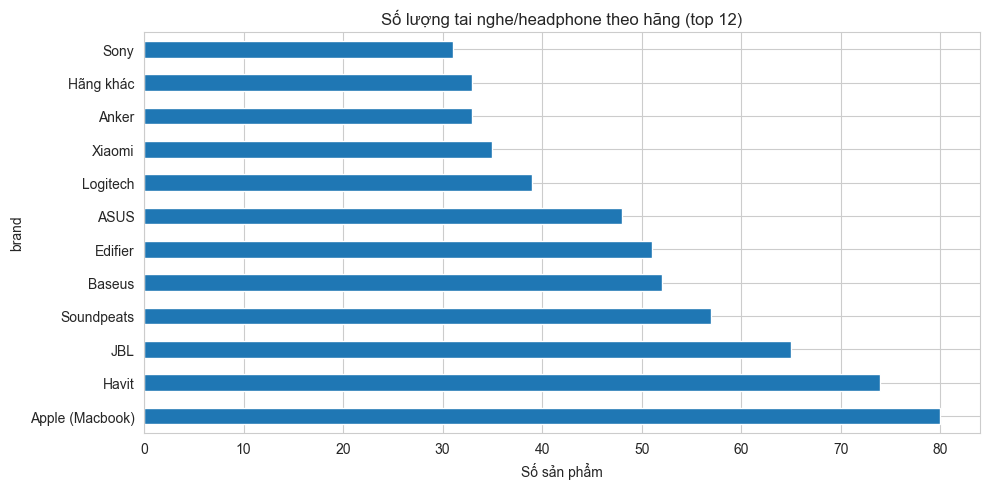

In [9]:
# Phân bố hãng (brand) — biến danh mục
if 'brand' in df.columns:
    brand_counts = df['brand'].value_counts()
    top_brands = brand_counts.head(12)
    if len(top_brands) > 0:
        plt.figure(figsize=(10, 5))
        top_brands.plot(kind='barh')
        plt.xlabel('Số sản phẩm')
        plt.title('Số lượng tai nghe/headphone theo hãng (top 12)')
        plt.tight_layout()
        plt.show()

---

## 3. Làm sạch và chuẩn hóa dữ liệu

### 3.1 Mô tả cách xử lý

- **Loại bỏ / xử lý missing:** Cột giá (`price_vnd`): bỏ dòng không có giá hoặc giá <= 0 (vì Y là giá). Các cột số như `driver_size_mm`, `impedance_ohm`, `sensitivity_db`, `battery_life_hours`, `weight_gram`, `rating`, `num_reviews` có thể điền trung vị hoặc giữ missing tùy chiến lược.
- **Chuẩn hóa kiểu dữ liệu:** Đảm bảo các cột số ở trên là int/float.
- **Loại bỏ trùng:** Xóa bản ghi trùng theo `url` hoặc `name` (nếu cùng URL/name).
- **Outlier:** Có thể giới hạn giá tai nghe trong khoảng hợp lý (ví dụ 0.1–20 triệu) hoặc ghi nhận và quyết định giữ/loại.

Sau đây: **trực quan hóa sự thay đổi phân bố trước và sau làm sạch.**

In [10]:
# Lưu bản "trước làm sạch" để so sánh
df_before = df.copy()
print('Số dòng trước làm sạch:', len(df_before))

Số dòng trước làm sạch: 1037


In [11]:
# Bước làm sạch
# 1) Chỉ giữ dòng có giá hợp lệ (Y)
if 'price_vnd' in df.columns:
    df = df[df['price_vnd'].notna() & (df['price_vnd'] > 0)]
    df['price_vnd'] = df['price_vnd'].astype(int)

# 2) Giới hạn giá trong khoảng hợp lý (triệu VND) — tùy chọn
MIN_PRICE, MAX_PRICE = 1e5, 2e7  # 0.1 tr - 20 tr
df = df[(df['price_vnd'] >= MIN_PRICE) & (df['price_vnd'] <= MAX_PRICE)]

# 3) Chuẩn hóa cột số
numeric_cols_to_clean = [
    'driver_size_mm', 'impedance_ohm', 'sensitivity_db', 'battery_life_hours',
    'weight_gram', 'warranty_months', 'rating', 'num_reviews'
]
for col in numeric_cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 4) Loại bỏ trùng theo url (nếu có)
if 'url' in df.columns:
    df = df.drop_duplicates(subset=['url'], keep='first')
else:
    df = df.drop_duplicates(keep='first')

print('Số dòng sau làm sạch:', len(df))

Số dòng sau làm sạch: 986


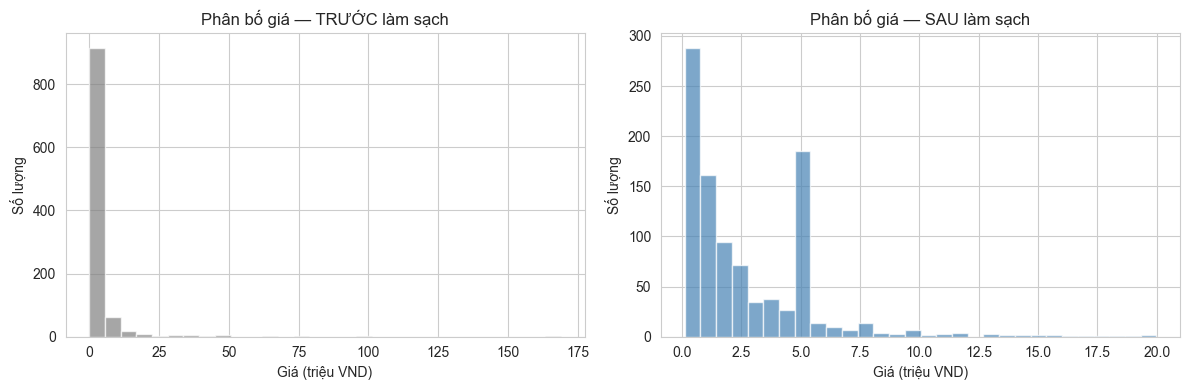

In [12]:
# Trực quan: phân bố giá TRƯỚC vs SAU làm sạch
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if 'price_vnd' in df_before.columns:
    p_before = df_before['price_vnd'].dropna()
    p_before = p_before[(p_before > 0) & (p_before <= 200e6)]
    axes[0].hist(p_before / 1e6, bins=30, color='gray', alpha=0.7, label='Trước')
    axes[0].set_xlabel('Giá (triệu VND)')
    axes[0].set_ylabel('Số lượng')
    axes[0].set_title('Phân bố giá — TRƯỚC làm sạch')

if 'price_vnd' in df.columns:
    axes[1].hist(df['price_vnd'] / 1e6, bins=30, color='steelblue', alpha=0.7, label='Sau')
    axes[1].set_xlabel('Giá (triệu VND)')
    axes[1].set_ylabel('Số lượng')
    axes[1].set_title('Phân bố giá — SAU làm sạch')

plt.tight_layout()
plt.show()

In [13]:
# Lưu clean data (dùng cho các bước sau)
os.makedirs(CLEAN_DIR, exist_ok=True)
clean_path = os.path.join(CLEAN_DIR, 'headphone_clean.csv')
df.to_csv(clean_path, index=False, encoding='utf-8')
print('Đã lưu clean data:', clean_path)

Đã lưu clean data: c:\Study\KHDL\GK\de_tai_2_headphone\clean_data\headphone_clean.csv


---

## 4. Mã hóa dữ liệu

Áp dụng cho **dữ liệu danh mục (category)** hoặc vector hóa text (NLP) nếu có.

- **Biến danh mục (brand, storage_type, os, …):** Dùng **One-Hot Encoding** hoặc **Label Encoding** tùy mô hình sau này.
- Ở đây minh họa: tạo cột `brand_encoded` (label) và có thể dùng `pd.get_dummies()` cho one-hot.

In [14]:
# Label encoding cho brand (ví dụ)
if 'brand' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le_brand = LabelEncoder()
    df['brand_encoded'] = le_brand.fit_transform(df['brand'].astype(str).fillna('Unknown'))
    print('Số nhãn brand:', len(le_brand.classes_))
    print(le_brand.classes_[:10])

Số nhãn brand: 103
[': Asus' ': Corsair' ': Logitech' 'AKG' 'ASUS' 'AULA' 'Acer'
 'Alpha Works' 'Anker' 'Apple']


In [15]:
# One-Hot cho một vài biến danh mục (ví dụ: storage_type nếu có)
cat_cols = [c for c in ['storage_type', 'os'] if c in df.columns]
if cat_cols:
    dummies = pd.get_dummies(df[cat_cols].astype(str).fillna('Unknown'), prefix=cat_cols)
    df = pd.concat([df, dummies], axis=1)
    print('Đã thêm one-hot cho:', list(dummies.columns))

---

## 5. Xây dựng và lựa chọn đặc trưng (Feature Engineering)

Xây dựng các đặc trưng mới từ biến gốc, hỗ trợ mô hình dự đoán giá.

- **price_per_battery_hour:** Giá / thời lượng pin (VND/giờ) — phản ánh "đắt đỏ" theo từng giờ nghe.
- **price_per_driver_mm:** Giá / kích thước driver (VND/mm).
- **is_wireless:** 0/1 — tai nghe không dây.
- **is_tws / is_gaming:** 0/1 — loại true-wireless / gaming.
- **has_anc, has_mic, water_resistant, gaming_features**: các biến nhị phân từ mô tả.
- **rating, num_reviews:** phản ánh độ phổ biến và mức độ hài lòng.

Có thể thêm các nhóm theo tầm giá, phân khúc (entry/mid/high-end) để trực quan hóa.

In [16]:
# Feature engineering

# price_per_battery_hour (triệu VND / giờ pin)
if 'battery_life_hours' in df.columns and df['battery_life_hours'].notna().any() and (df['battery_life_hours'] > 0).any():
    df['price_per_battery_hour'] = (df['price_vnd'] / 1e6) / df['battery_life_hours'].replace(0, np.nan)

# price_per_driver_mm (triệu VND / mm driver)
if 'driver_size_mm' in df.columns and df['driver_size_mm'].notna().any() and (df['driver_size_mm'] > 0).any():
    df['price_per_driver_mm'] = (df['price_vnd'] / 1e6) / df['driver_size_mm'].replace(0, np.nan)

# is_wireless, is_tws, is_gaming từ cột type/connection (nếu có)
if 'connection' in df.columns:
    conn = df['connection'].astype(str).str.lower()
    df['is_wireless'] = conn.str.contains('wireless', na=False).astype(int)
else:
    df['is_wireless'] = 0

if 'type' in df.columns:
    t = df['type'].astype(str).str.lower()
    df['is_tws'] = t.str.contains('true wireless|tws', na=False).astype(int)
    df['is_gaming'] = t.str.contains('gaming', na=False).astype(int)
else:
    df['is_tws'] = 0
    df['is_gaming'] = 0

print('Các cột hiện có:', df.columns.tolist())

Các cột hiện có: ['source', 'url', 'name', 'price_raw', 'price_vnd', 'brand', 'type', 'is_gaming', 'is_wireless', 'has_mic', 'connection', 'battery_life_hours', 'weight_gram', 'brand_encoded', 'price_per_battery_hour', 'is_tws']


---

## 6. Trực quan hóa mối quan hệ đa biến

Dùng **scatter plot, correlation map, distribution plot, lmplot, clustermap** để khám phá mối quan hệ tiềm ẩn giữa các biến. Có thể thêm **t-SNE** để trực quan không gian nhiều chiều (tính chất cụm).

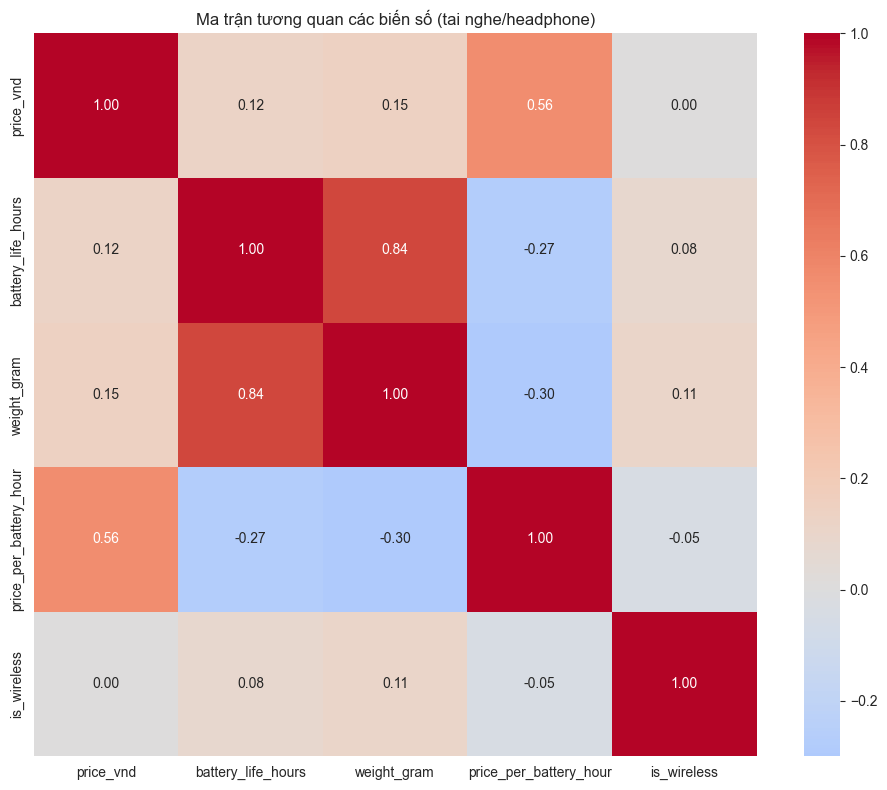

In [17]:
# Ma trận tương quan (các biến số)
num_cols = [
    'price_vnd', 'driver_size_mm', 'impedance_ohm', 'sensitivity_db',
    'battery_life_hours', 'weight_gram', 'rating', 'num_reviews',
    'price_per_battery_hour', 'price_per_driver_mm', 'is_wireless', 'has_anc',
]
num_cols = [c for c in num_cols if c in df.columns]
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
    plt.title('Ma trận tương quan các biến số (tai nghe/headphone)')
    plt.tight_layout()
    plt.show()

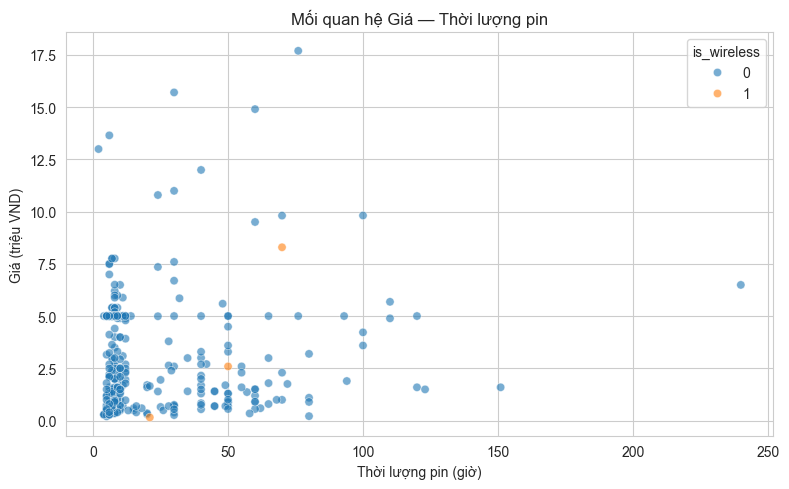

In [18]:
# Scatter: Giá vs kích thước driver
if 'driver_size_mm' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='driver_size_mm', y=df['price_vnd']/1e6, hue='brand' if 'brand' in df.columns else None, alpha=0.6)
    plt.xlabel('Kích thước driver (mm)')
    plt.ylabel('Giá (triệu VND)')
    plt.title('Mối quan hệ Giá — Kích thước driver')
    if 'brand' in df.columns:
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Scatter: Giá vs thời lượng pin (nếu có)
if 'battery_life_hours' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='battery_life_hours', y=df['price_vnd']/1e6, hue='is_wireless' if 'is_wireless' in df.columns else None, alpha=0.6)
    plt.xlabel('Thời lượng pin (giờ)')
    plt.ylabel('Giá (triệu VND)')
    plt.title('Mối quan hệ Giá — Thời lượng pin')
    plt.tight_layout()
    plt.show()

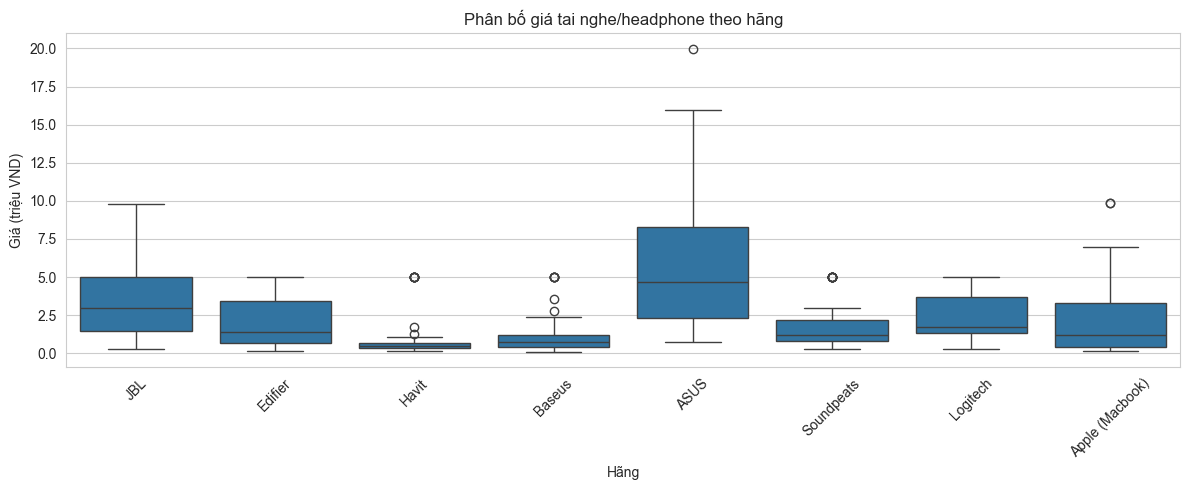

In [19]:
# Boxplot: Giá theo hãng (một vài hãng có nhiều mẫu)
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().head(8).index.tolist()
    df_plot = df[df['brand'].isin(top_brands)]
    if len(df_plot) > 0:
        plt.figure(figsize=(12, 5))
        sns.boxplot(data=df_plot, x='brand', y=df_plot['price_vnd']/1e6)
        plt.xticks(rotation=45)
        plt.xlabel('Hãng')
        plt.ylabel('Giá (triệu VND)')
        plt.title('Phân bố giá tai nghe/headphone theo hãng')
        plt.tight_layout()
        plt.show()

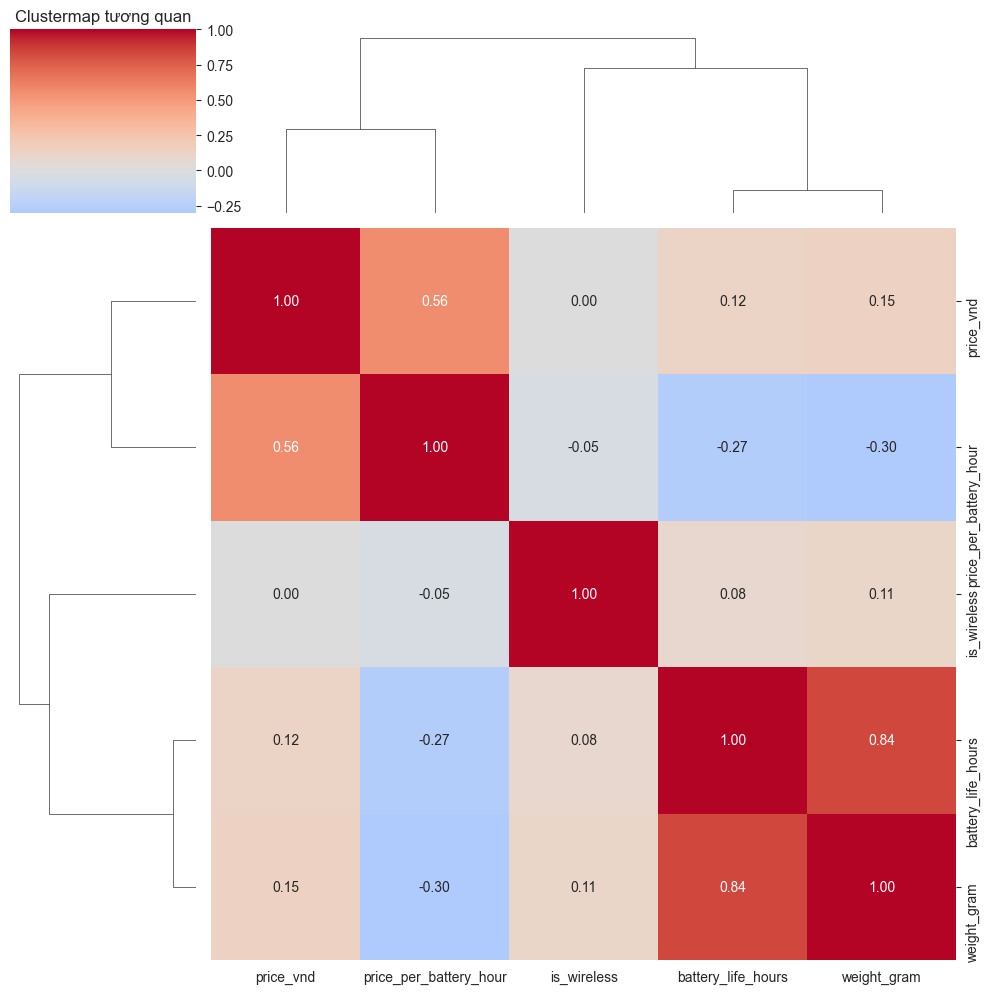

In [20]:
# Clustermap (tương quan + clustering hàng/cột)
if len(num_cols) >= 3:
    sns.clustermap(df[num_cols].dropna(how='all').corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Clustermap tương quan')
    plt.tight_layout()
    plt.show()

### 6.1 Trực quan hóa không gian nhiều chiều (t-SNE) — tùy chọn

Dùng t-SNE để giảm chiều dữ liệu số và vẽ 2D, xem tính chất cụm (cluster) của dữ liệu đầu vào.

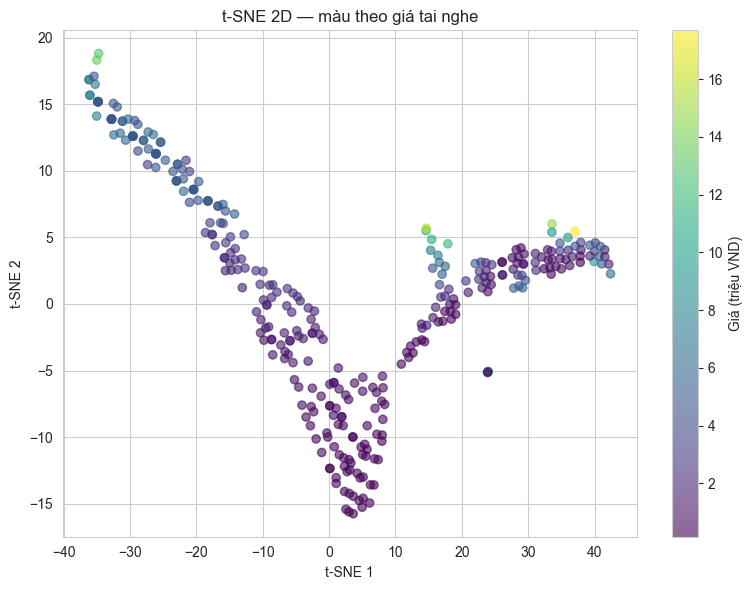

In [21]:
# Chuẩn hóa và t-SNE (chỉ chạy khi có đủ dữ liệu số)
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

feat_cols = [c for c in ['driver_size_mm', 'impedance_ohm', 'battery_life_hours', 'price_per_battery_hour', 'is_wireless'] if c in df.columns]
df_tsne = df[feat_cols + ['price_vnd']].dropna(how='any')
if len(df_tsne) > 50 and len(feat_cols) >= 2:
    X = StandardScaler().fit_transform(df_tsne[feat_cols])
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(df_tsne)-1))
    X_tsne = tsne.fit_transform(X)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df_tsne['price_vnd']/1e6, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Giá (triệu VND)')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.title('t-SNE 2D — màu theo giá tai nghe')
    plt.tight_layout()
    plt.show()
else:
    print('Không đủ dữ liệu hoặc cột để chạy t-SNE (cần >50 mẫu sau dropna và >=2 đặc trưng).')

---

## 7. Kết luận

1. **Bài toán có khả thi không?**  
   - Có. Dữ liệu thu thập được có **biến mục tiêu Y (price_vnd)** rõ ràng và **nhiều biến giải thích X** (hãng, loại tai nghe, kiểu kết nối, kích thước driver, trở kháng, thời lượng pin, ANC, đánh giá, số review, …). Nếu số mẫu đủ lớn (≥ 400–500) và các biến số cho thấy tương quan với giá, việc xây dựng mô hình hồi quy dự đoán giá tai nghe/headphone là **khả thi**.

2. **Tập đặc trưng hữu ích có thể dùng để xây dựng mô hình?**  
   - **Đặc trưng số:** `driver_size_mm`, `impedance_ohm`, `sensitivity_db`, `battery_life_hours`, `weight_gram`, `rating`, `num_reviews`, `price_per_battery_hour`, `price_per_driver_mm`.
   - **Đặc trưng nhị phân:** `has_anc`, `has_mic`, `water_resistant`, `gaming_features`, `is_wireless`, `is_tws`, `is_gaming`.
   - **Đặc trưng danh mục đã mã hóa:** `brand` (one-hot hoặc label), `type`, `connection` (one-hot), các nhóm phân khúc giá.

*(Nhóm cần điền bổ sung nhận xét dựa trên kết quả thực tế sau khi chạy notebook với dữ liệu crawl.)*

---

## 8. Tài liệu tham khảo

- Gợi ý nguồn dữ liệu: `gearvn.com`, `cellphones.com.vn`, `phongvu.vn`, `pcpartpicker.com`, Tiki/Shopee (category tai nghe/headphone).
- Kỹ thuật Feature Engineering: https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- Giới thiệu t-SNE: https://www.datacamp.com/tutorial/introduction-t-sne
- Cách trình bày notebook tham khảo: folder mẫu 10-Data-Capstone-Projects (GV cung cấp).